## Importando as bibliotecas necessárias

In [78]:
import os
from requests import post, get
import json
from base64 import b64encode
from dotenv import load_dotenv
load_dotenv()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Definindo as variáveis iniciais

In [59]:
client_id = os.environ['CLIENT_ID_SPOTIFY']
client_secret = os.environ['CLIENT_SECRET_SPOTIFY']
base_url = 'https://accounts.spotify.com/api/token'

## Criando as funções para acesso
### Requisitando a autorização

In [76]:
def request_auth(client_id, client_secret, base_url):
    """
    Input's a json and returns a pandas DataFrame
    """
    b64_encoded = b64encode(f'{client_id}:{client_secret}'.encode())
    auth_b64 = str(b64_encoded, 'utf-8')
    
    auth_options = {
        'url': base_url,
        'headers':{
            'Authorization': 'Basic ' + auth_b64,
            'content-type': 'application/x-www-form-urlencoded'
        },
        'form':{
            'grant_type': 'client_credentials'
        },
        'json': True
    }

    request = post(url=auth_options['url'], headers=auth_options['headers'], data=auth_options['form'])
    if request.status_code == 200:
        json_request = request.json()
        access_token = json_request['access_token']
        token_type = json_request['token_type']
        token_expires = json_request['expires_in']
        print('Acesso autorizado e dados extraídos!')
    else:
        print('Acesso não autorizado!')
        
    return access_token, token_type, token_expires

In [77]:
access_token, token_type, token_expires = request_auth(client_id=client_id, client_secret=client_secret, base_url=base_url)

Acesso autorizado e dados extraídos!


### Extraindo a playlist

In [74]:
def get_playlist(playlist, token_type, access_token, offset=0, limit=100):
    playlist_id = playlist.split('/')[-1].split('?')[0]
    endpoint = f'https://api.spotify.com/v1/playlists/{playlist_id}/tracks?offset={str(offset)}&limit={str(limit)}'
    headers={
        'Authorization': token_type + ' ' + access_token
    }

    response = get(url=endpoint, headers=headers)
    if response.status_code != 200:
        print('Error! Dados não extraídos')

    return response.json()

### Extraindo as features da música

In [91]:
def track_features(track_id, token_type, access_token):
    endpoint = f'https://api.spotify.com/v1/audio-features/{track_id}'
    headers={
        'Authorization': token_type + ' ' + access_token
    }

    response = get(url=endpoint, headers=headers)
    
    if response.status_code != 200:
        print('Error! Dados não extraídos')

    return response.json()

### Transformando o json retornado da `get_playlist` em um DataFrame do `pandas`.

In [87]:
def playlist_to_dataframe(playlist_endpoint, token_type, access_token, offset=0, limit=100, label=None):
    """
    Input's a playlist url and returns a pandas DataFrame
    """
    examples = []
    playlist = get_playlist(playlist=playlist_endpoint, token_type=token_type, access_token=access_token, offset=offset, limit=limit)
    
    for page in range(limit, playlist['total'] + 1, limit):
        m = len(playlist['items'])
        for i in range(m):
            track = playlist['items'][i]['track']
            track_feature = track_features(track['id'], token_type, access_token)


            # Lista para adicionar cada exemplo m
            example = [
                track['id'],
                track['name'],
                track['artists'][0]['name'],
                track['duration_ms'],
                track['popularity'],
                track_feature['danceability'],
                track_feature['energy'],
                track_feature['key'],
                track_feature['loudness'],
                track_feature['mode'],
                track_feature['speechiness'],
                track_feature['acousticness'],
                track_feature['instrumentalness'],
                track_feature['liveness'],
                track_feature['valence'],
                track_feature['tempo']
            ]


            examples.append(example)
        
        playlist = get_playlist(playlist=playlist_endpoint, token_type=token_type, access_token=access_token, offset=page, limit=limit)
    
    features = ['id', 'name', 'artists', 'duration_ms', 'popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
               'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
    df = pd.DataFrame(examples, columns=features)
    
    if label == 0:
        df['y'] = 0
    elif label == 1:
        df['y'] = 1
    
    return df, playlist

#### Playlists

In [88]:
good_songs = 'https://open.spotify.com/playlist/6DI0NiX9bE3fIF6cEoI2zL?si=ef8a610d53f64627'
bad_songs = 'https://open.spotify.com/playlist/6IBody2iNg5TgmAeYiHYpW?si=xsEvNjbbQYqt0rs9wP3yOg'

### Good Songs

In [ ]:
df_good, playlist = playlist_to_dataframe(good_songs, token_type, access_token, offset=0, limit=100, label=1)
df_good.head()

In [90]:
df_good.shape

(600, 17)

In [95]:
df_good.to_csv('df_good.csv')

In [92]:
df_good['artists'].value_counts().sort_values(ascending=False)

artists
Iron Maiden           40
System Of A Down      34
Alanis Morissette     14
Mamonas Assassinas    13
ANGRA                 11
                      ..
Brujeria               1
Legião Urbana          1
Swingin' Utters        1
Bad Religion           1
Drake Bell             1
Name: count, Length: 282, dtype: int64

In [93]:
print(f'Duração média: {np.mean(df_good["duration_ms"]) / 60:.2f}min\nPopularidade média: {np.mean(df_good["popularity"]):.1f}')

Duração média: 3912.99min
Popularidade média: 41.1


### Bad Songs

In [97]:
df_bad, _ = playlist_to_dataframe(bad_songs, token_type, access_token, offset=0, limit=100, label=0)
df_bad.head()

,id,name,artists,duration_ms,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,y
0,76oTcfNSAGS1cmzVTjof5e,Sua filha é puta,MC Levin,168250,28,0.684,0.443,5,-6.753,0,0.3230,0.4940,0.003050,0.0288,0.629,88.506,0
1,2kWowyDGD9yOL0WQzni20m,Vou Parar de Tomar Gin,Mc IG,162046,0,0.802,0.520,0,-6.973,1,0.2530,0.4470,0.000000,0.0942,0.956,160.054,0
2,142YjJNOuXjzeSDnB1ujw1,Sua amiga deu,MC Levin,178173,57,0.947,0.556,7,-4.536,1,0.0736,0.2770,0.000005,0.2080,0.426,130.046,0
3,0jlLqG8aydyDjZkJ0ShmPg,Capital das Notas,MC Menor Mr,184000,0,0.719,0.565,3,-5.924,1,0.2120,0.3090,0.000000,0.0768,0.643,82.732,0
4,5PNJXjGx8PAFooqCRuTUIv,Casal Bonnie e Clyde,Mc Magal,190907,49,0.552,0.491,1,-5.261,1,0.3120,0.0789,0.000000,0.0471,0.765,86.041,0


In [98]:
df_bad.to_csv('df_bad.csv')

In [99]:
df_bad.shape

(300, 17)

In [100]:
df_bad['artists'].value_counts().sort_values(ascending=False)

artists
Mc 7 Belo          9
Mc Magrinho        7
Mc Brisola         6
MC Timbu           5
Mc Mãozinha        4
                  ..
Mc Kevin           1
MC Dog             1
MC Gury            1
DJ Leozinho MPC    1
Mc Leléto          1
Name: count, Length: 167, dtype: int64

In [101]:
print(f'Duração média: {np.mean(df_bad["duration_ms"]) / 60:.2f}min\nPopularidade média: {np.mean(df_bad["popularity"])}')

Duração média: 2904.74min
Popularidade média: 10.716666666666667


## EDA

### Popularity

Text(0.5, 1.0, 'Good vs Bad Popularity')

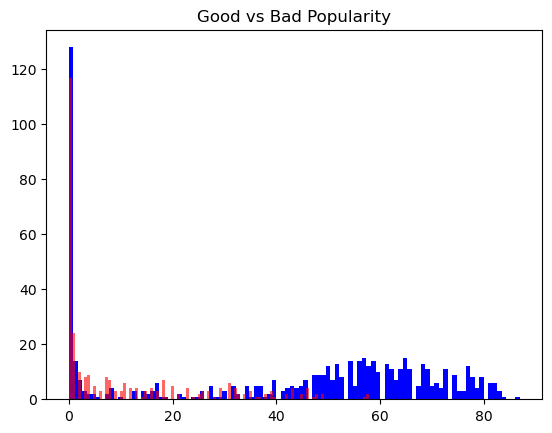

In [103]:
plt.hist(df_good['popularity'], color='b', bins=100)
plt.hist(df_bad['popularity'], alpha=0.6, color='r', bins=100)
plt.title('Good vs Bad Popularity')

### Duration ms

Text(0.5, 1.0, 'Good vs Bad Duration')

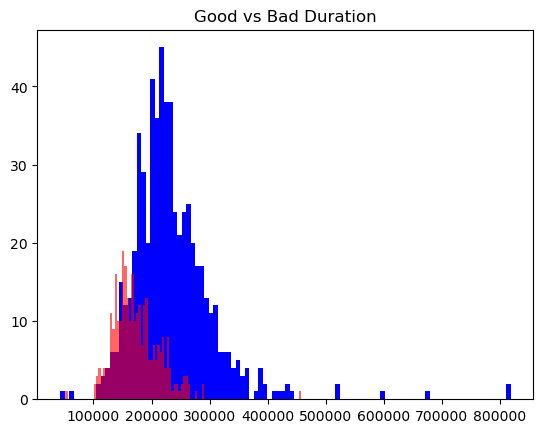

In [104]:
plt.hist(df_good['duration_ms'], color='b', bins=100)
plt.hist(df_bad['duration_ms'], alpha=0.6, color='r', bins=100)
plt.title('Good vs Bad Duration')

In [105]:
features = ['id', 'name', 'popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
good = df_good[features]
good

,id,name,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,1XNdu4czbxZ9tdVOhDtI4M,Cheia de Manias,51,0.707,0.614,7,-9.377,0,0.0580,0.1980,0.000000,0.1770,0.9570,156.473
1,1SaeGiWS1LQhfRc6ObQfvq,Que Se Chama Amor,0,0.647,0.528,7,-12.739,1,0.0409,0.4110,0.000000,0.0481,0.6210,136.118
2,6jBZxE0VZpmgZud4L5lo0u,Paparico,54,0.738,0.850,9,-7.278,1,0.0756,0.5300,0.000000,0.2130,0.9670,88.799
3,43uHeQc9kdMzFAbxCTcgiI,Telegrama,54,0.517,0.516,11,-12.441,1,0.0342,0.4430,0.000004,0.2360,0.6010,151.060
4,4tILvSk9XcdCBzjyzhsuze,É Tarde Demais,50,0.615,0.403,4,-11.648,1,0.0282,0.4250,0.000004,0.3210,0.4540,136.377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,7F5GuFWbBqMURqPQjfAeC3,Fences,0,0.588,0.740,2,-6.901,0,0.0287,0.0806,0.001210,0.3730,0.5040,112.989
596,6Kh1uaN6zhSyfLb6HaYGqC,"Love Like a Sunset, Pt. I",0,0.629,0.538,11,-10.116,0,0.0300,0.4930,0.888000,0.1020,0.2610,124.993
597,7rCYiUnMGloBwREKrFkbf9,"Love Like a Sunset, Pt. II",0,0.552,0.435,3,-9.031,1,0.0368,0.5680,0.187000,0.1050,0.0546,115.904
598,5bYQM8TrQ6ur1SuEieE3pK,Lasso,0,0.645,0.630,11,-7.066,1,0.0354,0.0253,0.000433,0.1250,0.9600,150.919


In [106]:
bad = df_bad[features]
bad

,id,name,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,76oTcfNSAGS1cmzVTjof5e,Sua filha é puta,28,0.684,0.443,5,-6.753,0,0.3230,0.49400,0.003050,0.0288,0.629,88.506
1,2kWowyDGD9yOL0WQzni20m,Vou Parar de Tomar Gin,0,0.802,0.520,0,-6.973,1,0.2530,0.44700,0.000000,0.0942,0.956,160.054
2,142YjJNOuXjzeSDnB1ujw1,Sua amiga deu,57,0.947,0.556,7,-4.536,1,0.0736,0.27700,0.000005,0.2080,0.426,130.046
3,0jlLqG8aydyDjZkJ0ShmPg,Capital das Notas,0,0.719,0.565,3,-5.924,1,0.2120,0.30900,0.000000,0.0768,0.643,82.732
4,5PNJXjGx8PAFooqCRuTUIv,Casal Bonnie e Clyde,49,0.552,0.491,1,-5.261,1,0.3120,0.07890,0.000000,0.0471,0.765,86.041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0JqfxHoQljxXEu7Hu7xQq5,Vou Te Fazer Só uma Pergunta,2,0.936,0.536,1,-4.298,1,0.3830,0.34100,0.000149,0.4490,0.414,130.042
296,3XzOzJiVXlmsaCsxMTEgaR,Ia Ia O,11,0.875,0.942,11,-4.888,0,0.3800,0.23800,0.000000,0.0771,0.712,130.156
297,50yUvsuECyUqd3TyurTjee,Fica Tranquila Vai Senta Na Vara,1,0.901,0.524,1,-0.318,1,0.1250,0.68900,0.000000,0.0871,0.788,132.126
298,4H3i9lgICE9Mo7V1ybBcii,Para de ficar fazendo fofoca ft. DJ LUCK MUZIK,2,0.796,0.668,8,-2.322,1,0.3940,0.19600,0.000000,0.1950,0.743,88.482


In [236]:
corr_good = good.iloc[:, 2:].corr()
corr_good

,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
popularity,1.000000,0.067757,0.126401,-0.150757,0.269411,-0.069206,0.148434,-0.248052,-0.107428,-0.153134,0.111011,0.060010
danceability,0.067757,1.000000,-0.266757,-0.003222,-0.159029,0.222444,-0.092200,0.165407,0.010736,-0.165431,0.334021,-0.231930
energy,0.126401,-0.266757,1.000000,-0.123715,0.766703,-0.244514,0.354713,-0.788201,0.022558,0.131022,0.391377,0.011292
key,-0.150757,-0.003222,-0.123715,1.000000,-0.138626,-0.154062,-0.057987,0.153602,-0.078316,-0.016031,0.058853,0.125194
loudness,0.269411,-0.159029,0.766703,-0.138626,1.000000,-0.249845,0.259511,-0.698026,-0.032255,-0.003244,0.304308,-0.010495
mode,-0.069206,0.222444,-0.244514,-0.154062,-0.249845,1.000000,-0.075863,0.239228,0.142998,0.011747,0.081781,-0.073312
speechiness,0.148434,-0.092200,0.354713,-0.057987,0.259511,-0.075863,1.000000,-0.273173,-0.028948,0.074888,0.187882,-0.109779
acousticness,-0.248052,0.165407,-0.788201,0.153602,-0.698026,0.239228,-0.273173,1.000000,-0.096871,0.016622,-0.270815,-0.021931
instrumentalness,-0.107428,0.010736,0.022558,-0.078316,-0.032255,0.142998,-0.028948,-0.096871,1.000000,-0.079854,-0.050522,-0.030543
liveness,-0.153134,-0.165431,0.131022,-0.016031,-0.003244,0.011747,0.074888,0.016622,-0.079854,1.000000,0.004643,0.200853


In [107]:
corr_badd = bad.iloc[:, 2:].corr()
corr_badd

,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
popularity,1.000000,-0.106808,0.039826,0.083835,-0.017867,-0.148778,-0.060379,0.017038,-0.051437,-0.008681,0.031321,-0.112767
danceability,-0.106808,1.000000,0.020675,-0.003444,0.103981,0.007405,-0.189908,-0.002774,0.078651,-0.063033,0.163366,0.226840
energy,0.039826,0.020675,1.000000,0.149975,0.550050,-0.022687,0.019016,-0.076937,0.024239,0.223219,0.157443,0.111674
key,0.083835,-0.003444,0.149975,1.000000,0.068024,-0.208568,-0.034945,-0.059424,0.081913,0.171629,0.016093,0.014871
loudness,-0.017867,0.103981,0.550050,0.068024,1.000000,-0.016519,-0.152692,0.029092,0.085123,-0.025338,0.003715,0.084522
mode,-0.148778,0.007405,-0.022687,-0.208568,-0.016519,1.000000,0.114486,0.011038,0.047390,-0.020629,-0.087507,0.140508
speechiness,-0.060379,-0.189908,0.019016,-0.034945,-0.152692,0.114486,1.000000,0.175058,-0.068774,0.130747,-0.069534,-0.114467
acousticness,0.017038,-0.002774,-0.076937,-0.059424,0.029092,0.011038,0.175058,1.000000,-0.061565,0.093996,0.032354,0.000468
instrumentalness,-0.051437,0.078651,0.024239,0.081913,0.085123,0.047390,-0.068774,-0.061565,1.000000,0.074380,0.025664,0.021221
liveness,-0.008681,-0.063033,0.223219,0.171629,-0.025338,-0.020629,0.130747,0.093996,0.074380,1.000000,-0.065108,-0.012182
